# Final Reproducible Pipeline — Cookie Cats

This notebook demonstrates **end-to-end reproducibility** by importing
every processing step from the project's `src/` modules.  Run all cells
in order to replicate the full analysis.

---

## Step 0 — Environment Setup

In [1]:
import sys, os, warnings
warnings.filterwarnings('ignore')

# Make src/ importable regardless of working directory
SRC_DIR = os.path.abspath(os.path.join(os.getcwd(), '..', 'src'))
if SRC_DIR not in sys.path:
    sys.path.insert(0, SRC_DIR)

# Reproducibility seed
RANDOM_STATE = 42

print(f'src path: {SRC_DIR}')
print('Setup complete ✓')

src path: d:\Data Science\src
Setup complete ✓


## Step 1 — Load Data

In [2]:
from processing import load_data

df_raw = load_data()
df_raw.head()

Dataset loaded: 90,189 rows × 5 columns


,userid,version,sum_gamerounds,retention_1,retention_7
0,116,gate_30,3,False,False
1,337,gate_30,38,True,False
2,377,gate_40,165,True,False
3,483,gate_40,1,False,False
4,488,gate_40,179,True,True


## Step 2 — Clean Data

In [3]:
from processing import preprocess_data

df_clean = preprocess_data(df_raw)
df_clean.info()

After cleaning: 90,189 rows
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90189 entries, 0 to 90188
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   userid          90189 non-null  int64 
 1   version         90189 non-null  object
 2   sum_gamerounds  90189 non-null  int64 
 3   retention_1     90189 non-null  int64 
 4   retention_7     90189 non-null  int64 
dtypes: int64(4), object(1)
memory usage: 3.4+ MB


## Step 3 — Feature Engineering

In [4]:
from processing import engineer_features

df_feat = engineer_features(df_clean)
df_feat.head()

Engineered features added. New shape: (90189, 9)


,userid,version,sum_gamerounds,retention_1,retention_7,gamerounds_bin,high_engagement,retention_1_x_rounds,rounds_per_day_proxy
0,116,gate_30,3,0,0,casual,0,0,0.428571
1,337,gate_30,38,1,0,moderate,0,38,5.428571
2,377,gate_40,165,1,0,active,1,165,23.571429
3,483,gate_40,1,0,0,inactive,0,0,0.142857
4,488,gate_40,179,1,1,active,1,179,25.571429


## Step 4 — Augment with Scraped Benchmarks

In [5]:
from scraping import scrape_industry_benchmarks, augment_dataset_with_benchmarks

benchmarks = scrape_industry_benchmarks()
df_augmented = augment_dataset_with_benchmarks(df_feat, benchmarks)
print('Industry columns added:', [c for c in df_augmented.columns if 'industry' in c])

Scraping industry benchmarks...
Industry columns added: ['industry_day_1_retention', 'industry_day_7_retention', 'industry_day_30_retention']


## Step 5 — Train / Test Split

In [6]:
from processing import prepare_modeling_data

X_train, X_test, y_train, y_test = prepare_modeling_data(
    df_feat, random_state=RANDOM_STATE
)

Train: 72,151  |  Test: 18,038
Positive-class rate (train): 0.1861


## Step 6 — Model Training (sklearn Pipeline)

In [7]:
from modeling import train_models

trained = train_models(X_train, y_train, random_state=RANDOM_STATE)

  Training Logistic Regression …
  Training Random Forest …
  Training XGBoost …
  Training Gradient Boosting …


## Step 7 — Hyperparameter Tuning

In [8]:
from modeling import tune_hyperparameters

xgb_tuned = tune_hyperparameters(X_train, y_train, 'XGBoost',
                                  random_state=RANDOM_STATE)
rf_tuned  = tune_hyperparameters(X_train, y_train, 'Random Forest',
                                  random_state=RANDOM_STATE)

# Add tuned models
trained['XGBoost (Tuned)']       = {'pipeline': xgb_tuned['best_pipeline']}
trained['Random Forest (Tuned)'] = {'pipeline': rf_tuned['best_pipeline']}

Tuning XGBoost (5-fold CV, scoring=roc_auc) …
  Best params : {'classifier__learning_rate': 0.1, 'classifier__max_depth': 3, 'classifier__n_estimators': 50}
  Best CV roc_auc: 0.8892
Tuning Random Forest (5-fold CV, scoring=roc_auc) …
  Best params : {'classifier__max_depth': 5, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 200}
  Best CV roc_auc: 0.8889


## Step 8 — Evaluation

In [9]:
from modeling import (
    evaluate_all_models, metrics_summary_df, get_best_model,
    plot_model_comparison, plot_roc_curves, plot_confusion_matrices,
)

eval_results = evaluate_all_models(trained, X_test, y_test)

# Summary table
summary = metrics_summary_df(eval_results)
display(summary.style.format('{:.4f}').highlight_max(axis=0, color='#d4edda'))

# Best model
best_name, best_score = get_best_model(eval_results)


 Logistic Regression
  Accuracy  : 0.8443
  Precision : 0.5614
  Recall    : 0.7470
  F1-score  : 0.6410
  ROC-AUC   : 0.8846

 Random Forest
  Accuracy  : 0.8086
  Precision : 0.4909
  Recall    : 0.7777
  F1-score  : 0.6019
  ROC-AUC   : 0.8783

 XGBoost
  Accuracy  : 0.8143
  Precision : 0.5007
  Recall    : 0.8004
  F1-score  : 0.6160
  ROC-AUC   : 0.8858

 Gradient Boosting
  Accuracy  : 0.8155
  Precision : 0.5026
  Recall    : 0.8039
  F1-score  : 0.6185
  ROC-AUC   : 0.8878

 XGBoost (Tuned)
  Accuracy  : 0.8159
  Precision : 0.5032
  Recall    : 0.8081
  F1-score  : 0.6202
  ROC-AUC   : 0.8883

 Random Forest (Tuned)
  Accuracy  : 0.8173
  Precision : 0.5057
  Recall    : 0.8045
  F1-score  : 0.6210
  ROC-AUC   : 0.8882


,Accuracy,Precision,Recall,F1,ROC-AUC
Model,,,,,
XGBoost (Tuned),0.8159,0.5032,0.8081,0.6202,0.8883
Random Forest (Tuned),0.8173,0.5057,0.8045,0.6210,0.8882
Gradient Boosting,0.8155,0.5026,0.8039,0.6185,0.8878
XGBoost,0.8143,0.5007,0.8004,0.6160,0.8858
Logistic Regression,0.8443,0.5614,0.7470,0.6410,0.8846
Random Forest,0.8086,0.4909,0.7777,0.6019,0.8783



★ Best model by roc_auc: XGBoost (Tuned) (0.8883)


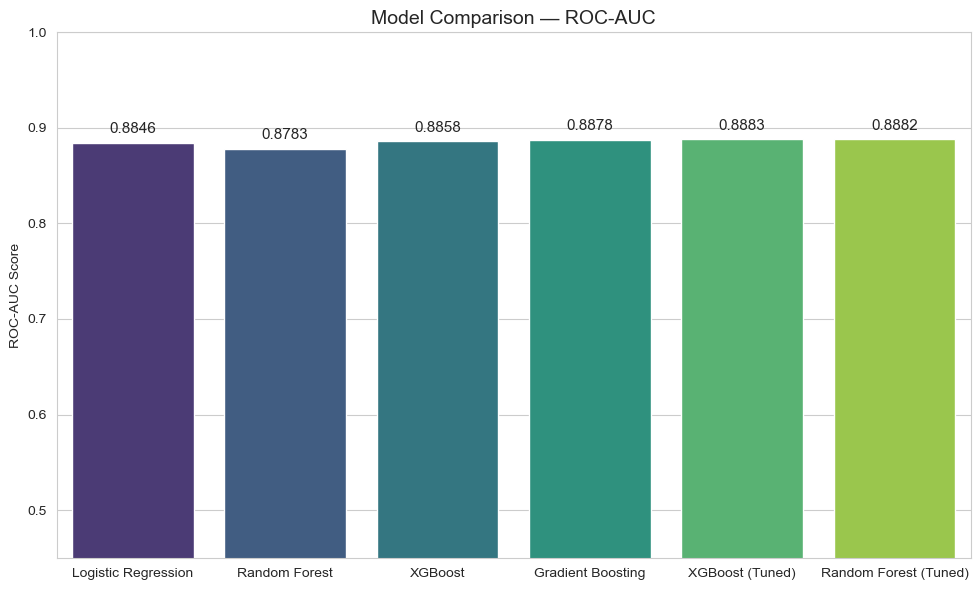

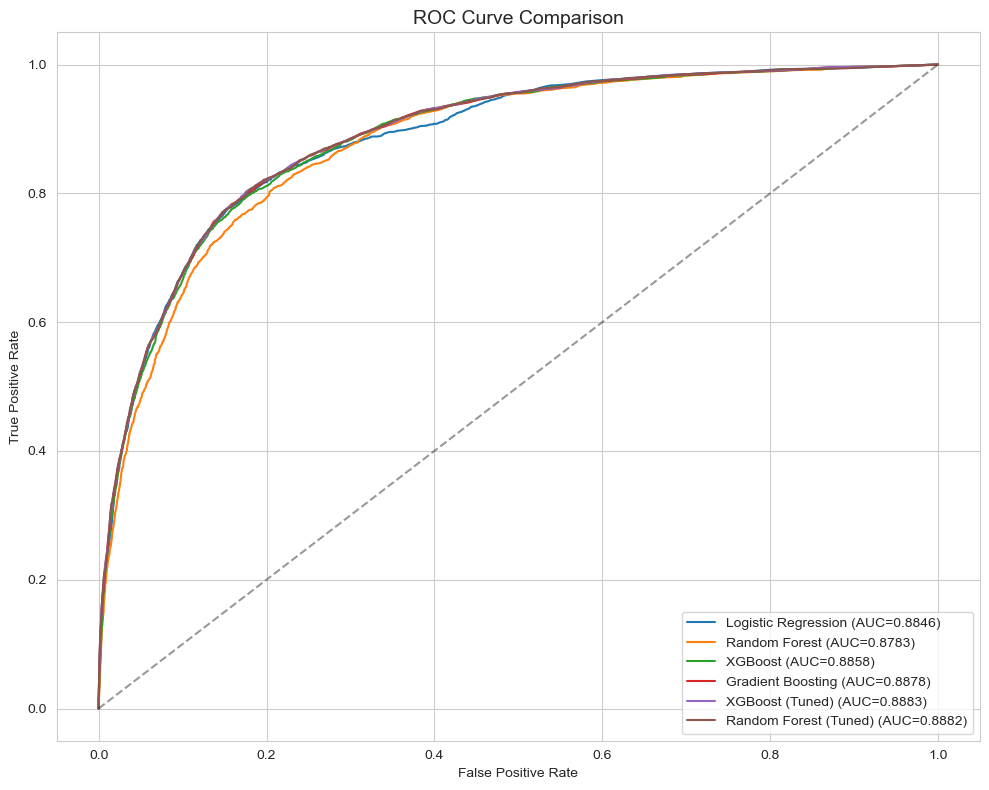

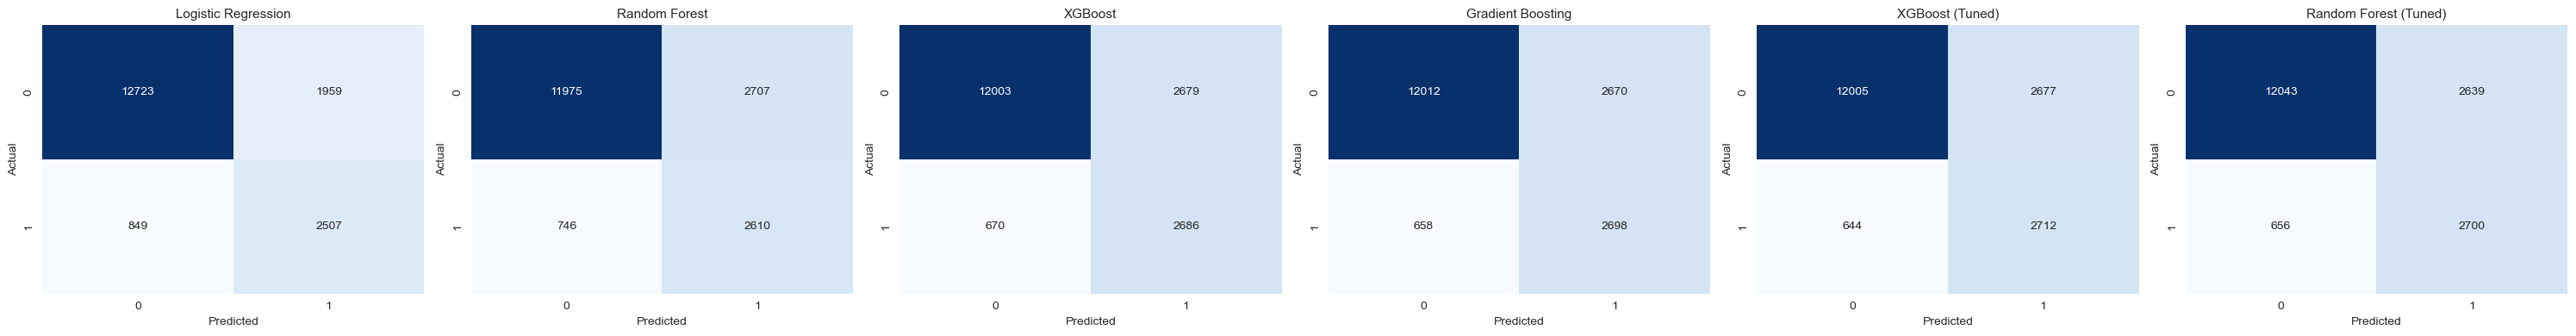

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')

plot_model_comparison(eval_results)
plot_roc_curves(eval_results, y_test)
plot_confusion_matrices(eval_results)

## Step 9 — A/B Test Verification

gate_30: 44,700  |  gate_40: 45,489


Bootstrapping: 100%|██████████| 1000/1000 [00:01<00:00, 803.68it/s]


Retention difference: -0.0082
p-value: 0.5040


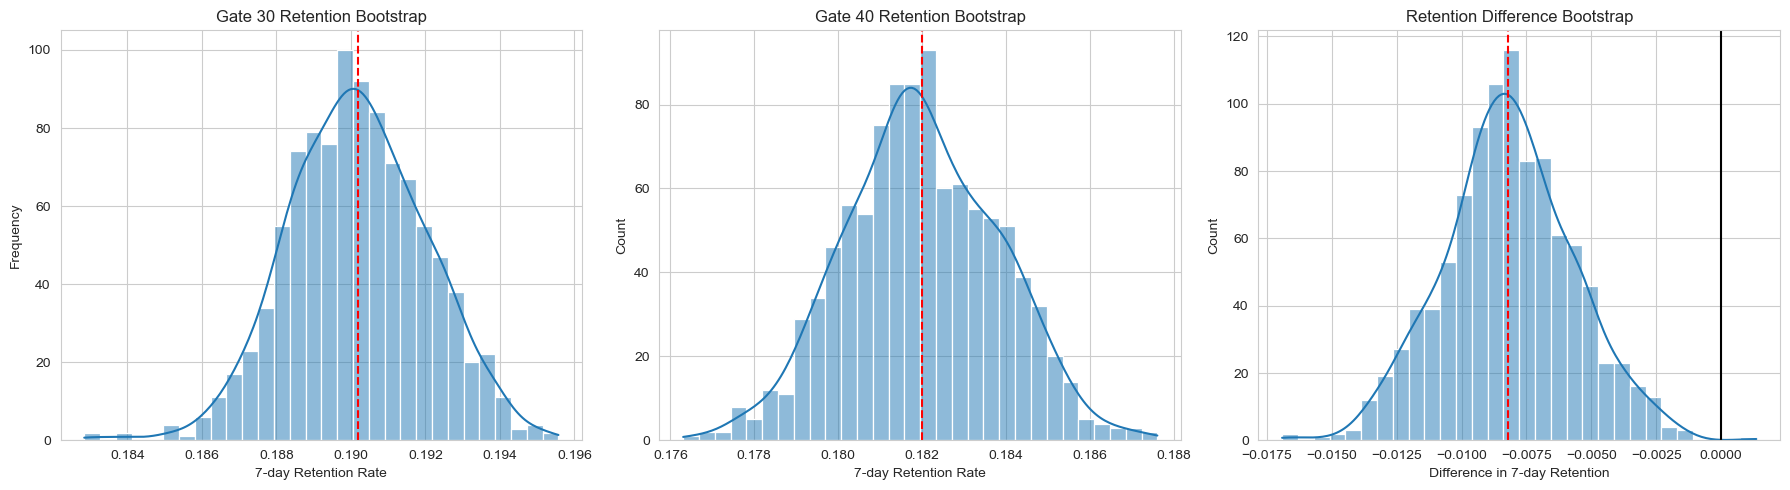

In [11]:
from processing import create_ab_groups
from ab_testing import analyze_ab_test, plot_bootstrap_results

gate_30, gate_40 = create_ab_groups(df_clean)
ab_results = analyze_ab_test(gate_30, gate_40, n_bootstraps=1000)

print(f"Retention difference: {ab_results['observed_retention']['difference']:.4f}")
print(f"p-value: {ab_results['p_value']:.4f}")
plot_bootstrap_results(ab_results)

---
## ✅ Pipeline Complete

All steps executed from `src/` modules in sequence.  To reproduce,
run **Kernel → Restart & Run All**.